# Machine Learning Assignment 2 - Purchase Intent Model Lab

**Student:** Richa Tripathi  
**BITS ID:** 2025AC05424  
**Programme:** BITS Pilani WILP M.Tech (AIML/DSE)  
**Course:** Machine Learning

## 1. Imports and reproducibility setup

In [29]:
from pathlib import Path
import platform
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    matthews_corrcoef, precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

ROOT = Path.cwd()
if not (ROOT / "data" / "online_shoppers_intention.csv").exists():
    raise FileNotFoundError("Open/run this notebook from the extracted repository root.")

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "Revenue"

NUMERIC_FEATURES = [
    "Administrative", "Administrative_Duration", "Informational",
    "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]
CATEGORICAL_FEATURES = [
    "Month", "OperatingSystems", "Browser", "Region",
    "TrafficType", "VisitorType", "Weekend"
]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
EXPECTED_COLUMNS = FEATURES + [TARGET]

print("Project root:", ROOT)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

Project root: /content
Python: 3.12.13
pandas: 2.2.2
scikit-learn: 1.6.1
joblib: 1.5.3


## 2. Dataset source and assignment threshold check

Dataset: **Online Shoppers Purchasing Intention Dataset**, UCI Machine Learning Repository, dataset ID 468.  
DOI: https://doi.org/10.24432/C5F88Q  
License: CC BY 4.0.

The assignment requires at least **12 input features** and **500 instances**. This source dataset contains 17 predictors and 12,330 raw sessions.

In [30]:
DATA_PATH = ROOT / "data" / "online_shoppers_intention.csv"
raw_df = pd.read_csv(DATA_PATH)

if list(raw_df.columns) != EXPECTED_COLUMNS:
    raise ValueError("Unexpected source schema or column order.")

raw_rows = len(raw_df)
raw_predictors = len(FEATURES)
missing_predictors = int(raw_df[FEATURES].isna().sum().sum())
missing_targets = int(raw_df[TARGET].isna().sum())

def normalize_target(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)
    mapping = {"true":1, "false":0, "1":1, "0":0, "1.0":1, "0.0":0}
    normalized = series.astype(str).str.strip().str.lower().map(mapping)
    if normalized.isna().any():
        raise ValueError("Unsupported Revenue target value detected.")
    return normalized.astype(int)

clean_df = raw_df.loc[raw_df[TARGET].notna()].copy()
clean_df[TARGET] = normalize_target(clean_df[TARGET])
exact_duplicates = int(clean_df.duplicated().sum())
conflicting_groups = int((clean_df.groupby(FEATURES, dropna=False)[TARGET].nunique() > 1).sum())
if conflicting_groups:
    raise ValueError("Identical feature rows with conflicting target labels were found.")
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

cleaned_rows = len(clean_df)

audit = pd.DataFrame({
    "Check": [
        "Raw rows", "Raw predictors", "Missing predictor values", "Missing target rows",
        "Exact duplicate rows removed", "Conflicting duplicate feature groups", "Cleaned usable rows"
    ],
    "Value": [
        raw_rows, raw_predictors, missing_predictors, missing_targets,
        exact_duplicates, conflicting_groups, cleaned_rows
    ]
})
display(audit)
assert raw_predictors >= 12
assert cleaned_rows >= 500
print("PASS: dataset satisfies the assignment feature and instance thresholds.")

,Check,Value
0,Raw rows,12330
1,Raw predictors,17
2,Missing predictor values,0
3,Missing target rows,0
4,Exact duplicate rows removed,125
5,Conflicting duplicate feature groups,0
6,Cleaned usable rows,12205


PASS: dataset satisfies the assignment feature and instance thresholds.


### Cleaning decision

Only deterministic pre-split cleaning is performed: target validation and removal of exact duplicate complete records.
Statistical outliers are not automatically deleted because large page counts or session durations may represent genuine shopping behaviour.
UCI reports no missing values, defensive imputers are nevertheless included inside the fitted pipelines for robust prediction.

In [31]:
class_counts = clean_df[TARGET].value_counts().sort_index()
class_table = pd.DataFrame({
    "Class": ["No Purchase (0)", "Purchase (1)"],
    "Count": [int(class_counts[0]), int(class_counts[1])],
    "Share": [class_counts[0]/len(clean_df), class_counts[1]/len(clean_df)]
})
display(class_table.style.format({"Share":"{:.2%}"}))
print("Positive class: Revenue = 1 (purchase session)")

,Class,Count,Share
0,No Purchase (0),10297,84.37%
1,Purchase (1),1908,15.63%


Positive class: Revenue = 1 (purchase session)


## 3. Feature roles

Integer-coded fields such as browser, region and traffic type are treated as categorical variables because the code values are category identifiers rather than numerical magnitudes.

In [32]:
schema_table = pd.DataFrame({
    "Feature": FEATURES,
    "Role": ["Numerical" if c in NUMERIC_FEATURES else "Categorical" for c in FEATURES]
})
display(schema_table)
assert TARGET not in FEATURES
print("PASS: Revenue is excluded from the input feature list.")

,Feature,Role
0,Administrative,Numerical
1,Administrative_Duration,Numerical
2,Informational,Numerical
3,Informational_Duration,Numerical
4,ProductRelated,Numerical
5,ProductRelated_Duration,Numerical
6,BounceRates,Numerical
7,ExitRates,Numerical
8,PageValues,Numerical
9,SpecialDay,Numerical


PASS: Revenue is excluded from the input feature list.


## 4. One frozen stratified train-test split

The cleaned dataset is split once using `random_state=42`, `test_size=0.20`, and stratification on `Revenue`. The same train and test rows are reused for all five models. No scaling, encoding, imputation, model fitting, or model selection uses the held-out test data.

In [33]:
X = clean_df[FEATURES].copy()
y = clean_df[TARGET].astype(int).copy()

train_idx, test_idx = train_test_split(
    clean_df.index.to_numpy(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
assert set(train_idx).isdisjoint(set(test_idx))

X_train, X_test = X.loc[train_idx].copy(), X.loc[test_idx].copy()
y_train, y_test = y.loc[train_idx].copy(), y.loc[test_idx].copy()

split_table = pd.DataFrame({
    "Partition": ["Train", "Test"],
    "Rows": [len(X_train), len(X_test)],
    "No Purchase (0)": [int((y_train==0).sum()), int((y_test==0).sum())],
    "Purchase (1)": [int((y_train==1).sum()), int((y_test==1).sum())],
})
display(split_table)
print("PASS: train and test indices are disjoint and the split is stratified/reproducible.")

,Partition,Rows,No Purchase (0),Purchase (1)
0,Train,9764,8238,1526
1,Test,2441,2059,382


PASS: train and test indices are disjoint and the split is stratified/reproducible.


## 5. Leakage-safe preprocessing and model definitions

All learned preprocessing is inside each scikit-learn `Pipeline`, so transformations are fitted on training data only.

- Logistic Regression: numerical median imputation + standardization; categorical imputation + one-hot encoding.
- Decision Tree: numerical median imputation without scaling; categorical imputation + one-hot encoding.
- kNN: numerical standardization because distance is scale-sensitive.
- Gaussian Naive Bayes: standardized numerical variables and dense one-hot categorical features. GaussianNB is used instead of MultinomialNB because standardized values can be negative.
- Random Forest: numerical imputation without scaling; categorical one-hot encoding.

In [34]:
def make_preprocessor(scale_numeric):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipe = Pipeline(numeric_steps)
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipe, NUMERIC_FEATURES),
        ("categorical", categorical_pipe, CATEGORICAL_FEATURES),
    ], remainder="drop")

models = {
    "Logistic Regression": Pipeline([
        ("preprocess", make_preprocessor(True)),
        ("classifier", LogisticRegression(max_iter=2000, solver="lbfgs")),
    ]),
    "Decision Tree": Pipeline([
        ("preprocess", make_preprocessor(False)),
        ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    "kNN": Pipeline([
        ("preprocess", make_preprocessor(True)),
        ("classifier", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "Gaussian Naive Bayes": Pipeline([
        ("preprocess", make_preprocessor(True)),
        ("classifier", GaussianNB()),
    ]),
    "Random Forest (Ensemble)": Pipeline([
        ("preprocess", make_preprocessor(False)),
        ("classifier", RandomForestClassifier(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
        )),
    ]),
}
print("Models defined:", ", ".join(models.keys()))

Models defined: Logistic Regression, Decision Tree, kNN, Gaussian Naive Bayes, Random Forest (Ensemble)


## 6. Train and evaluate all five required classifiers

Required metrics are Accuracy, AUC, Precision, Recall, F1, and MCC. AUC is computed from the model's probability for positive class `Revenue=1`, not from hard class predictions. Precision, Recall, and F1 also treat label 1 as the positive class.

In [35]:
def positive_probability(model, X_data):
    probabilities = model.predict_proba(X_data)
    classes = list(model.classes_)
    if 1 not in classes:
        raise ValueError("Positive class 1 not found in fitted model classes.")
    return probabilities[:, classes.index(1)]


def evaluate_model(model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_score = positive_probability(model, X_data)
    metrics = {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "AUC": float(roc_auc_score(y_true, y_score)),
        "Precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=np.nan)),
        "Recall": float(recall_score(y_true, y_pred, pos_label=1, zero_division=np.nan)),
        "F1": float(f1_score(y_true, y_pred, pos_label=1, zero_division=np.nan)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
    }
    if not all(np.isfinite(v) for v in metrics.values()):
        raise ValueError(f"Undefined/non-finite required metric: {metrics}")
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    report = classification_report(
        y_true, y_pred, labels=[0,1],
        target_names=["No Purchase (0)", "Purchase (1)"],
        output_dict=True, zero_division=0,
    )
    return metrics, cm, report

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = evaluate_model(model, X_test, y_test)
    print("Finished:", name)

metrics_table = pd.DataFrame([
    {"ML Model Name": name, **results[name][0]} for name in models
])
display(metrics_table.style.format({
    "Accuracy":"{:.6f}", "AUC":"{:.6f}", "Precision":"{:.6f}",
    "Recall":"{:.6f}", "F1":"{:.6f}", "MCC":"{:.6f}"
}))

Finished: Logistic Regression
Finished: Decision Tree
Finished: kNN
Finished: Gaussian Naive Bayes
Finished: Random Forest (Ensemble)


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.886932,0.899574,0.752381,0.413613,0.533784,0.503190
1,Decision Tree,0.855797,0.737555,0.537313,0.565445,0.551020,0.465406
2,kNN,0.873413,0.795780,0.662222,0.390052,0.490939,0.443539
3,Gaussian Naive Bayes,0.277345,0.750246,0.175587,0.979058,0.297771,0.137533
4,Random Forest (Ensemble),0.906596,0.925592,0.776978,0.565445,0.654545,0.612257


## 7. Confusion matrices

Each matrix uses the order `[0, 1]` = `[No Purchase, Purchase]`

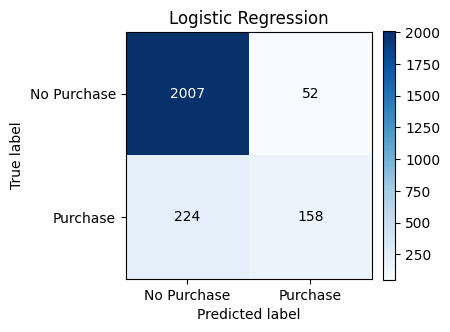

Matrix total: 2441 | Test rows: 2441


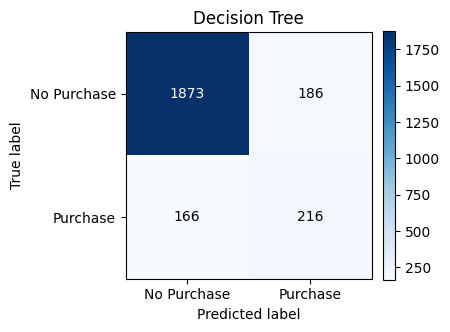

Matrix total: 2441 | Test rows: 2441


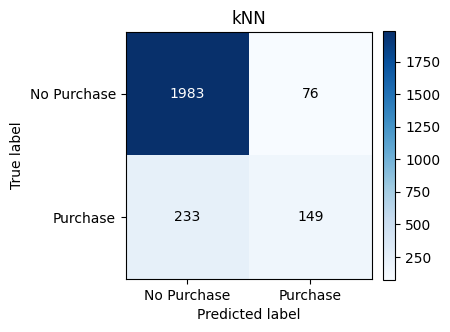

Matrix total: 2441 | Test rows: 2441


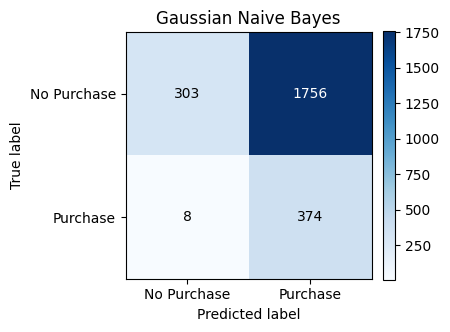

Matrix total: 2441 | Test rows: 2441


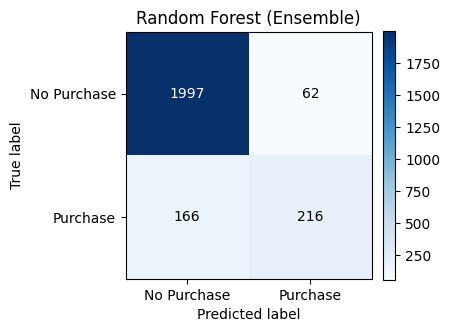

Matrix total: 2441 | Test rows: 2441


In [36]:
for name in models:
    cm = results[name][1]
    fig, ax = plt.subplots(figsize=(4.4, 3.8))
    image = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0,1], labels=["No Purchase", "Purchase"])
    ax.set_yticks([0,1], labels=["No Purchase", "Purchase"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    threshold = cm.max()/2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                    color="white" if cm[i,j] > threshold else "black")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    assert cm.sum() == len(X_test)
    print("Matrix total:", int(cm.sum()), "| Test rows:", len(X_test))

## 8. Classification reports

In [37]:
for name in models:
    print("\n", name)
    report_df = pd.DataFrame(results[name][2]).T
    display(report_df.round(4))


 Logistic Regression


,precision,recall,f1-score,support
No Purchase (0),0.8996,0.9747,0.9357,2059.0000
Purchase (1),0.7524,0.4136,0.5338,382.0000
accuracy,0.8869,0.8869,0.8869,0.8869
macro avg,0.8260,0.6942,0.7347,2441.0000
weighted avg,0.8766,0.8869,0.8728,2441.0000



 Decision Tree


,precision,recall,f1-score,support
No Purchase (0),0.9186,0.9097,0.9141,2059.0000
Purchase (1),0.5373,0.5654,0.5510,382.0000
accuracy,0.8558,0.8558,0.8558,0.8558
macro avg,0.7280,0.7376,0.7326,2441.0000
weighted avg,0.8589,0.8558,0.8573,2441.0000



 kNN


,precision,recall,f1-score,support
No Purchase (0),0.8949,0.9631,0.9277,2059.0000
Purchase (1),0.6622,0.3901,0.4909,382.0000
accuracy,0.8734,0.8734,0.8734,0.8734
macro avg,0.7785,0.6766,0.7093,2441.0000
weighted avg,0.8585,0.8734,0.8594,2441.0000



 Gaussian Naive Bayes


,precision,recall,f1-score,support
No Purchase (0),0.9743,0.1472,0.2557,2059.0000
Purchase (1),0.1756,0.9791,0.2978,382.0000
accuracy,0.2773,0.2773,0.2773,0.2773
macro avg,0.5749,0.5631,0.2767,2441.0000
weighted avg,0.8493,0.2773,0.2623,2441.0000



 Random Forest (Ensemble)


,precision,recall,f1-score,support
No Purchase (0),0.9233,0.9699,0.9460,2059.0000
Purchase (1),0.7770,0.5654,0.6545,382.0000
accuracy,0.9066,0.9066,0.9066,0.9066
macro avg,0.8501,0.7677,0.8003,2441.0000
weighted avg,0.9004,0.9066,0.9004,2441.0000


## 9. Model-performance observations and overall winner

Because the positive class is less frequent, the winner is not selected using Accuracy alone. MCC and F1 are especially useful for judging balanced classification performance, with AUC, Precision, Recall, and Accuracy used as supporting evidence.

In [38]:
m = metrics_table.set_index("ML Model Name")
observations = pd.DataFrame({
    "ML Model Name": [
        "Logistic Regression", "Decision Tree", "kNN",
        "Gaussian Naive Bayes", "Random Forest (Ensemble)"
    ],
    "Observation": [
        f"Strong AUC ({m.loc['Logistic Regression','AUC']:.4f}) and Precision ({m.loc['Logistic Regression','Precision']:.4f}), but lower Recall ({m.loc['Logistic Regression','Recall']:.4f}) means many purchase sessions are missed.",
        f"Recall ({m.loc['Decision Tree','Recall']:.4f}) is useful, but AUC ({m.loc['Decision Tree','AUC']:.4f}) and MCC ({m.loc['Decision Tree','MCC']:.4f}) are below the strongest model.",
        f"Accuracy is {m.loc['kNN','Accuracy']:.4f}, while Recall is only {m.loc['kNN','Recall']:.4f}, so many purchase sessions are classified as non-purchases.",
        f"Recall is very high ({m.loc['Gaussian Naive Bayes','Recall']:.4f}) but Precision is only {m.loc['Gaussian Naive Bayes','Precision']:.4f}; the model generates many false positives and weak overall balance.",
        f"Strongest overall balance with Accuracy {m.loc['Random Forest (Ensemble)','Accuracy']:.4f}, AUC {m.loc['Random Forest (Ensemble)','AUC']:.4f}, F1 {m.loc['Random Forest (Ensemble)','F1']:.4f}, and MCC {m.loc['Random Forest (Ensemble)','MCC']:.4f}."
    ]
})
display(observations)
winner = metrics_table.loc[metrics_table["MCC"].idxmax(), "ML Model Name"]
print("Overall winner:", winner)

,ML Model Name,Observation
0,Logistic Regression,"Strong AUC (0.8996) and Precision (0.7524), bu..."
1,Decision Tree,"Recall (0.5654) is useful, but AUC (0.7376) an..."
2,kNN,"Accuracy is 0.8734, while Recall is only 0.390..."
3,Gaussian Naive Bayes,Recall is very high (0.9791) but Precision is ...
4,Random Forest (Ensemble),Strongest overall balance with Accuracy 0.9066...


Overall winner: Random Forest (Ensemble)


## 10. Save the fitted model pipelines and exact held-out test data

The notebook itself contains the complete modelling code. The `model/` directory stores the five **fitted pipelines** used by `app.py`, so the deployed Streamlit application does not train models at startup.

In [39]:
MODEL_DIR = ROOT / "model"
MODEL_DIR.mkdir(exist_ok=True)
model_files = {
    "Logistic Regression": "logistic_regression.joblib",
    "Decision Tree": "decision_tree.joblib",
    "kNN": "knn.joblib",
    "Gaussian Naive Bayes": "naive_bayes.joblib",
    "Random Forest (Ensemble)": "random_forest.joblib",
}

for name, filename in model_files.items():
    joblib.dump(models[name], MODEL_DIR / filename, compress=3)
    print("Saved:", MODEL_DIR / filename)

# test_data.csv = exact untouched raw test predictors plus true target.
test_data = X_test.copy()
test_data[TARGET] = y_test.astype(int)
test_data.to_csv(ROOT / "test_data.csv", index=False)
print("Saved:", ROOT / "test_data.csv", "| Rows:", len(test_data))

for filename in model_files.values():
    loaded = joblib.load(MODEL_DIR / filename)
    assert len(loaded.predict(X_test.head(10))) == 10
print("PASS: every saved fitted model reloads and predicts raw test rows.")

Saved: /content/model/logistic_regression.joblib
Saved: /content/model/decision_tree.joblib
Saved: /content/model/knn.joblib
Saved: /content/model/naive_bayes.joblib
Saved: /content/model/random_forest.joblib
Saved: /content/test_data.csv | Rows: 2441
PASS: every saved fitted model reloads and predicts raw test rows.


## 11. Final execution evidence

In [40]:
print("ASSIGNMENT EXECUTION COMPLETED SUCCESSFULLY")
print("Student: Richa Tripathi")
print("BITS ID: 2025AC05424")
print("Dataset: UCI Online Shoppers Purchasing Intention")
print(f"Cleaned rows: {len(clean_df):,} | Predictors: {len(FEATURES)} | Test rows: {len(X_test):,}")
display(metrics_table.style.format({
    "Accuracy":"{:.4f}", "AUC":"{:.4f}", "Precision":"{:.4f}",
    "Recall":"{:.4f}", "F1":"{:.4f}", "MCC":"{:.4f}"
}))
print("All five fitted model files and test_data.csv were saved successfully.")
print("All five required models were evaluated on identical held-out test rows.")
print("Overall winner: Random Forest (Ensemble).")

ASSIGNMENT EXECUTION COMPLETED SUCCESSFULLY
Student: Richa Tripathi
BITS ID: 2025AC05424
Dataset: UCI Online Shoppers Purchasing Intention
Cleaned rows: 12,205 | Predictors: 17 | Test rows: 2,441


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8869,0.8996,0.7524,0.4136,0.5338,0.5032
1,Decision Tree,0.8558,0.7376,0.5373,0.5654,0.5510,0.4654
2,kNN,0.8734,0.7958,0.6622,0.3901,0.4909,0.4435
3,Gaussian Naive Bayes,0.2773,0.7502,0.1756,0.9791,0.2978,0.1375
4,Random Forest (Ensemble),0.9066,0.9256,0.7770,0.5654,0.6545,0.6123


All five fitted model files and test_data.csv were saved successfully.
All five required models were evaluated on identical held-out test rows.
Overall winner: Random Forest (Ensemble).
